In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import os
from typing import Dict
import pickle
from scipy.stats import linregress


def set_default_plot_style():
    plt.style.use("default")  # start clean

    plt.rcParams["axes.grid"] = True
    plt.rcParams["grid.alpha"] = 0.2
    plt.rcParams["grid.linestyle"] = "-"
    plt.rcParams["grid.color"] = "gray"

    plt.rcParams["axes.spines.top"] = False
    plt.rcParams["axes.spines.right"] = False

    plt.rcParams["axes.linewidth"] = 1.2

    plt.rcParams["legend.frameon"] = False

    plt.rcParams["font.size"] = 25
    plt.rcParams["axes.labelsize"] = 35
    plt.rcParams["legend.fontsize"] = 21


    mpl.rcParams['text.usetex'] = True
    mpl.rcParams['font.family'] = 'serif'
    mpl.rcParams['font.serif'] = ['Computer Modern Roman']

# Call once at the top of your script
set_default_plot_style()


In [7]:
# Helpful funcs
def log_b(x, b):
    return np.log(x) / np.log(b)


In [8]:
L_vals = [25000]
epsilon_prime_c = 0.212925
epsilon_prime_vals = [round(epsilon_prime_c + 0.0001 * i, ndigits = 6) for i in range(-2,3)]

# epsilon_prime_c = 0.2128
# epsilon_prime_vals = [round(epsilon_prime_c + 0.0001 * i, ndigits = 6) for i in range(-4,5)]
# epsilon_prime_vals.remove(0.2125)
# time_prefact = 150

time_prefact = 100

num_initial_conds = 12000
num_init_conds_offset = 0
initial_state_prob = 0.5

time_step = 1000

cmap = plt.colormaps.get_cmap("Oranges").resampled(len(epsilon_prime_vals) + 5)

read_external_drive = True
write_external_drive = read_external_drive and True
local_data_parent_folder = "data"
second_data_parent_folder = "/Volumes/ExternalData/stavskya_mc/data"
if read_external_drive:
    data_parent_folder = "/Volumes/ExternalData/stavskya_mc/data"
    if write_external_drive:
        local_data_parent_folder = "/Volumes/ExternalData/stavskya_mc/data"      
        second_data_parent_folder = "data"
else:
    data_parent_folder = local_data_parent_folder

# If first time

In [3]:


collected_rhos = {}
collected_rho_stds = {}

for L_val in L_vals:
    print(f"L_val: {L_val}")

    T_f = L_val*time_prefact
    collected_rhos[L_val] = {}
    collected_rho_stds[L_val] = {}

    collected_rhos[L_val] = {}
    collected_rho_stds[L_val] = {}

    for epsilon_prime in epsilon_prime_vals:
        print(f"L_val: {L_val} | epsilon: {epsilon_prime}")
        epsilon_val_name = f"{epsilon_prime}".replace(".", "p")

        current_rhos = np.array([[0.0 for _ in range(L_val * time_prefact // time_step)] for _ in range(num_initial_conds)])
        for init_cond in range(1, num_initial_conds+1):
            sample_filepath_name = os.path.join(data_parent_folder, f"time_rand_binary/rho_per_time/IC1/L{L_val}/epsilon{epsilon_val_name}/IC1_L{L_val}_epsilon{epsilon_val_name}_timepref{time_prefact}_timestep{time_step}_sample{init_cond}.csv")
                
            try:
                df = pd.read_csv(sample_filepath_name)

                current_rhos[init_cond-1] = df.rho
            except Exception as e:
                print(e)
                print(sample_filepath_name)
        
        collected_rhos[L_val][epsilon_prime] = np.mean(current_rhos.T, axis=1)
        collected_rho_stds[L_val][epsilon_prime] = np.std(current_rhos.T, axis=1)

        pickle_path = os.path.join(local_data_parent_folder, f"time_rand_binary/rho_per_time/IC{num_initial_conds}/L{L_val}/epsilon{epsilon_val_name}/IC{num_initial_conds}_L{L_val}_epsilon{epsilon_val_name}_timepref{time_prefact}_timestep{time_step}")
        second_pickle_path = os.path.join(second_data_parent_folder, f"time_rand_binary/rho_per_time/IC{num_initial_conds}/L{L_val}/epsilon{epsilon_val_name}/IC{num_initial_conds}_L{L_val}_epsilon{epsilon_val_name}_timepref{time_prefact}_timestep{time_step}")
                                                                
        dir_path = os.path.dirname(pickle_path)
        os.makedirs(dir_path, exist_ok=True)
        
        with open(pickle_path + "mean.pickle", "wb") as f:
            pickle.dump(collected_rhos[L_val][epsilon_prime], f)
        with open(pickle_path + "stds.pickle", "wb") as f:
            pickle.dump(collected_rho_stds[L_val][epsilon_prime], f)

        try:
            dir_path = os.path.dirname(second_pickle_path)
            os.makedirs(dir_path, exist_ok=True)
            with open(second_pickle_path + "mean.pickle", "wb") as f:
                pickle.dump(collected_rhos[L_val][epsilon_prime], f)
            with open(second_pickle_path + "stds.pickle", "wb") as f:
                pickle.dump(collected_rho_stds[L_val][epsilon_prime], f)
        except Exception as E:
            print(E)

NameError: name 'L_vals' is not defined

In [ ]:
print(sample_filepath_name)

/Volumes/ExternalData/stavskya_mc/data/time_rand_binary/rho_per_time/IC1/L20000/epsilon0p2127/IC1_L20000_epsilon0p2127_timepref200_timestep10000_sample4000.csv


## If you have already processed and saved the data as pickled

In [9]:

collected_rhos = {}
collected_rho_stds = {}

for L_val in L_vals:
    print(f"L_val: {L_val}")

    T_f = L_val*time_prefact
    collected_rhos[L_val] = {}
    collected_rho_stds[L_val] = {}

    collected_rhos[L_val] = {}
    collected_rho_stds[L_val] = {}
    for epsilon_prime in epsilon_prime_vals:
        epsilon_val_name = f"{epsilon_prime}".replace(".", "p")
        try:
            pickle_path = os.path.join(local_data_parent_folder, f"time_rand_binary/rho_per_time/IC{num_initial_conds}/L{L_val}/epsilon{epsilon_val_name}/IC{num_initial_conds}_L{L_val}_epsilon{epsilon_val_name}_timepref{time_prefact}_timestep{time_step}")

            with open(pickle_path + "mean.pickle", "rb") as f:
                collected_rhos[L_val][epsilon_prime] = pickle.load(f)
            with open(pickle_path + "stds.pickle", "rb") as f:
                collected_rho_stds[L_val][epsilon_prime] = pickle.load(f)

        except:
            pickle_path = os.path.join(local_data_parent_folder, f"time_rand_binary/rho_per_time/IC{3999}/L{L_val}/epsilon{epsilon_val_name}/IC{3999}_L{L_val}_epsilon{epsilon_val_name}_timepref{150}_timestep{time_step}")

            with open(pickle_path + "mean.pickle", "rb") as f:
                collected_rhos[L_val][epsilon_prime] = pickle.load(f)
            with open(pickle_path + "stds.pickle", "rb") as f:
                collected_rho_stds[L_val][epsilon_prime] = pickle.load(f)

L_val: 25000


In [ ]:
collected_rhos[L_vals[0]][epsilon_prime_vals[0]] == collected_rhos[L_vals[0]][epsilon_prime_vals[1]]

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

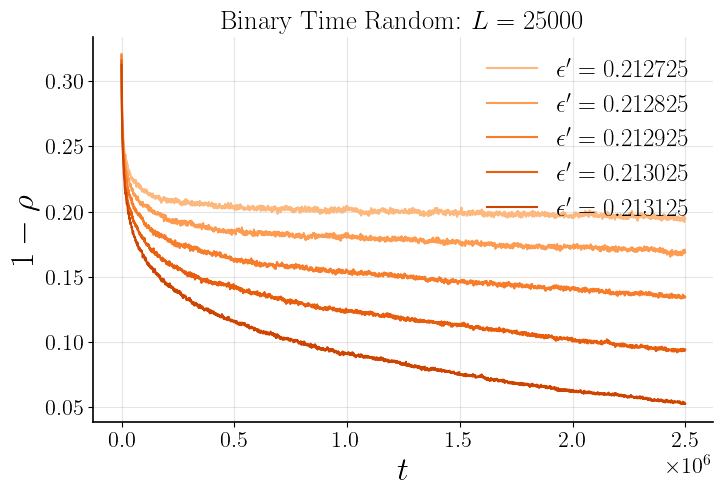

In [5]:
plt.figure(figsize=(8,5))

for j, L in enumerate(L_vals):
    for i, epsilon_val in enumerate(epsilon_prime_vals):
        c = cmap(i+3)
        time_vals = [i * time_step for i in range(0, L*time_prefact // time_step)]
        plt.plot(
            time_vals[:], 
            1-collected_rhos[L][epsilon_val][:len(time_vals)], 
            label = fr"$\epsilon' = {epsilon_val}$",
            # fmt='--',  
            # markersize=3,
            # marker = "o",
            # capsize=3,
            c=c
            )
    # plt.axvline(0.29450750, c = 'k', label=f"x = 0.29450750 (old trans)")
    plt.title(fr"Binary Time Random: $L = {L}$")
    plt.xlabel(r"$t$")
    plt.ylabel(r"$1 - \rho$")
    plt.legend()
    # plt.ylim(0.025, 0.325)

    plt.show()


In [ ]:
epsilon_prime_vals = sorted(epsilon_prime_vals)

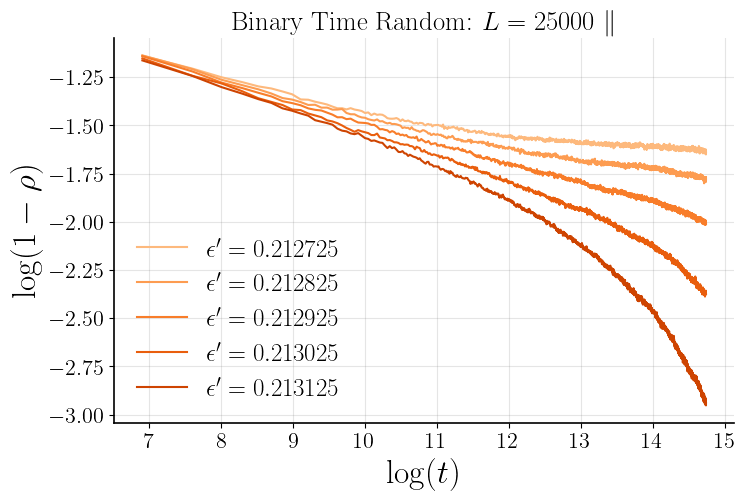

In [6]:
plt.figure(figsize=(8,5))

for j, L in enumerate(L_vals):
    for i, epsilon_val in enumerate(epsilon_prime_vals):
        c = cmap(i+3)
        time_vals = [i * time_step for i in range(1, L*time_prefact // time_step)]
        log_time_vals = np.log(np.array(time_vals))
        data_to_plot = np.log(1-collected_rhos[L][epsilon_val][:len(log_time_vals)])
        plt.plot(
            log_time_vals[:], 
            data_to_plot[:], 
            label = fr"$\epsilon' = {round(epsilon_val, ndigits=7)}$",
            # fmt='--',  
            # markersize=3,
            # marker = "o",
            # capsize=3,
            c=c
            )
    # plt.axvline(0.29450750, c = 'k', label=f"x = 0.29450750 (old trans)")
    plt.title(fr"Binary Time Random: $L = {L}$ $\|$")
    plt.xlabel(r"$\log(t)$")
    plt.ylabel(r"$\log(1 - \rho)$")
    plt.legend()
    # plt.ylim(-3.5, -1)

    plt.show()


/var/folders/0k/n4x5z88x1rx124p1g1l55hmc0000gn/T/ipykernel_44747/3606049817.py:13: RuntimeWarning: divide by zero encountered in divide
  np.log((1/np.array(time_vals))[0:-1]),


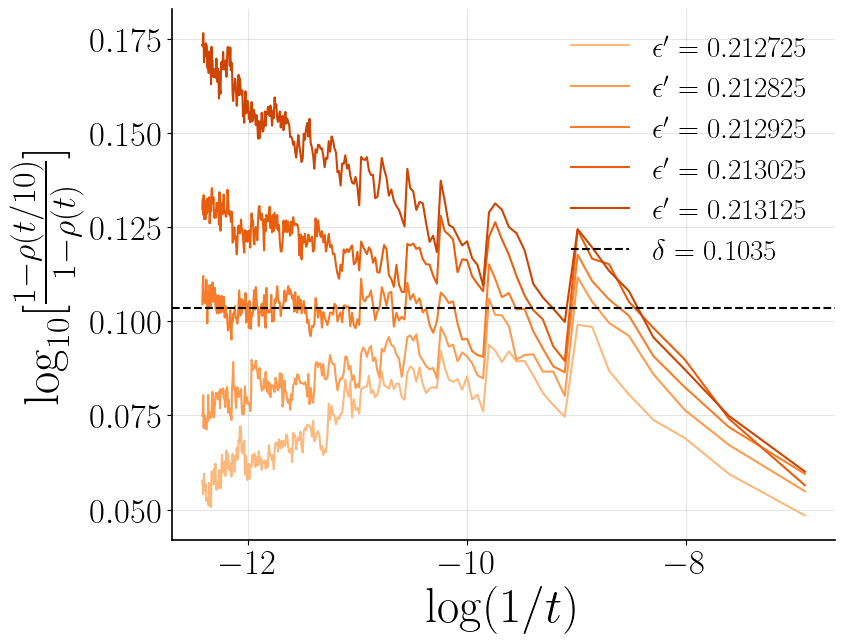

In [13]:
b = 10
delta_guess = 0.1035
plt.figure(figsize=(9,7))
for j, L in enumerate(L_vals):
    for i, epsilon_val in enumerate(epsilon_prime_vals):
        c = cmap(i+3)
        time_vals = [i * time_step for i in range(0, L*100 // (b * time_step))]
        data_to_plot = (1-collected_rhos[L][epsilon_val])
        data_to_plot_numerator = np.array([data_to_plot[(t//(b*time_step))] for t in time_vals])
        data_to_plot_denomenator = np.array([data_to_plot[t//time_step] for t in time_vals])
        data_to_plot = log_b(data_to_plot_numerator[:len(data_to_plot_denomenator)]/data_to_plot_denomenator, 10)
        plt.plot(
            np.log((1/np.array(time_vals))[0:-1]), 
            data_to_plot[1:], 
            label = fr"$\epsilon' = {epsilon_val}$",
            # fmt='--',  
            # markersize=3,
            # marker = "o",
            # capsize=3,
            c=c
            )
    
    
    plt.axhline(delta_guess, c = 'k', label=fr"$\delta = {delta_guess}$", linestyle ="--")
    # plt.title(fr"Binary Time Random: $L = {L}$ $\|$")
    plt.xlabel(r"$\log(1/t)$")
    plt.ylabel(r"$\log_{10}[\frac{1-\rho(t/10)}{1-\rho(t)}]$")
    plt.legend()
    # plt.xlim((np.log(0.000005), np.log(0.0005)))
    # plt.ylim((0.1, 0.25))
    plt.tight_layout()
    plt.savefig(f"figs/time_random/binary/binstav_determining_ac_delta.png")
    plt.show()

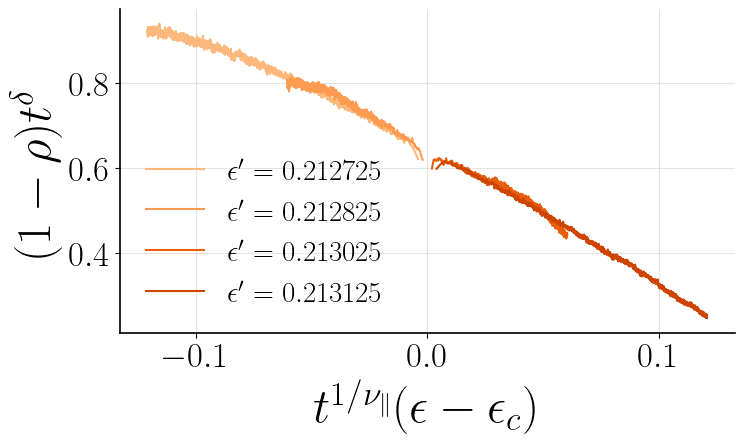

In [14]:
delta_guess = 0.1055
guess_nu_par = 2.3
epsilon_c = 0.212925
for j, L in enumerate(L_vals):
    plt.figure(figsize=(8,5))
    for i, epsilon_val in enumerate(epsilon_prime_vals):
        if epsilon_val == epsilon_c:
            continue
        c = cmap(i+3)
        time_vals = np.array([i * time_step for i in range(0, L*100 // time_step)])
        orig_data = (1-collected_rhos[L][epsilon_val])[0:len(time_vals)]
        plt.plot(
            (time_vals**(1/guess_nu_par)*(epsilon_val - epsilon_c))[1:], 
            (orig_data * time_vals ** delta_guess)[1:], 
            label = fr"$\epsilon' = {epsilon_val}$",
            # fmt='--',  
            # markersize=3,
            # marker = "o",
            # capsize=3,
            c=c
            )
    
    # plt.axvline(0.29450750, c = 'k', label=f"x = 0.29450750 (old trans)")
    # plt.title(fr"Time Random Binary: $L = {L}$ $\|$ $\delta = {delta_guess}$ $\|$ $\nu_{{\|}} = {guess_nu_par}$")
    plt.xlabel(r"$t^{1/\nu_{\|}}(\epsilon - \epsilon_c)$")
    plt.ylabel(r"$(1 - \rho)t^\delta$")
    plt.legend()
    # plt.xlim(0.0003, 0.16)
    # plt.ylim(0.3, 1.1)

    plt.tight_layout()
    plt.savefig(f"figs/time_random/binary/binstav_determining_nupar.png")
    plt.show()

In [20]:
print(guess_nu_par*delta_guess)
print(np.sqrt((guess_nu_par*0.002)**2 + (delta_guess*0.2)**2))

0.22155
0.021513948963405114


# By hand collpase
The expected form (near the crit pt) is

$(1-\rho)t^{\beta/\nu_{\|}} \sim g(t^{-z})$